# Classificação de dígitos manuscritos

Mini-projeto avaliativo — Módulo 02.

**Estado:** análise exploratória, divisão estratificada e normalização concluídas. KNN, Random Forest, MLP e CNN comparados na validação, com diagramas das redes. Temperatura da CNN ajustada no conjunto de calibração; avaliação final no teste pendente.

## 1. Configuração do ambiente

In [1]:
import os
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from time import perf_counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
# Configure antes de importar o TensorFlow; use um kernel reiniciado.
# Reduz os logs nativos da biblioteca; exceções Python permanecem visíveis.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
import visualkeras
from PIL import ImageFont
from matplotlib import font_manager
from IPython.display import display
import json
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp, softmax

In [2]:
RANDOM_STATE = 42
CACHE_DIR = Path("data/cache")
FIGURES_DIR = Path("reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### Verificação

A execução deve utilizar Python 3.12 no ambiente virtual do projeto.

In [3]:
print(f"Python: {sys.version.split()[0]}")
print(f"Ambiente virtual ativo: {sys.prefix != sys.base_prefix}")

bibliotecas = ["numpy", "pandas", "matplotlib", "scikit-learn", "ipykernel", "tensorflow", "keras", "visualkeras"]
pd.DataFrame({
    "Biblioteca": bibliotecas,
    "Versão": [version(nome) for nome in bibliotecas],
})

Python: 3.12.13
Ambiente virtual ativo: True


,Biblioteca,Versão
0,numpy,2.5.3
1,pandas,3.0.5
2,matplotlib,3.11.1
3,scikit-learn,1.9.0
4,ipykernel,7.3.0
5,tensorflow,2.21.0
6,keras,3.15.1
7,visualkeras,0.2.0


## 2. Carregamento e análise exploratória — Fase 1

Fonte: [MNIST no OpenML, conjunto 554](https://www.openml.org/d/554), `mnist_784`, versão 1. As verificações desta etapa descrevem a base integral; não são medidas de desempenho de um modelo.

In [4]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto",
    data_home=str(CACHE_DIR),
)

X = mnist.data
y = mnist.target.astype(np.uint8)

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)

Dimensões de X: (70000, 784)
Dimensões de y: (70000,)


### Estrutura e integridade

In [5]:
assert X.shape == (70_000, 784)
assert y.shape == (70_000,)
assert np.array_equal(np.unique(y), np.arange(10))
assert np.isfinite(X).all()
assert X.min() >= 0 and X.max() <= 255

pd.Series({
    "Imagens": X.shape[0],
    "Pixels por imagem": X.shape[1],
    "Tipo dos pixels": str(X.dtype),
    "Tipo dos rótulos": str(y.dtype),
    "Menor intensidade": X.min(),
    "Maior intensidade": X.max(),
    "Valores ausentes em X": int(np.isnan(X).sum()),
}, name="Diagnóstico").to_frame()

,Diagnóstico
Imagens,70000
Pixels por imagem,784
Tipo dos pixels,int64
Tipo dos rótulos,uint8
Menor intensidade,0
Maior intensidade,255
Valores ausentes em X,0


### Distribuição dos dígitos

In [6]:
contagens = pd.Series(y).value_counts().sort_index()
distribuicao = pd.DataFrame({
    "Quantidade": contagens,
    "Percentual (%)": contagens / len(y) * 100,
})
distribuicao.index.name = "Dígito"

assert distribuicao["Quantidade"].sum() == len(y)
assert np.isclose(distribuicao["Percentual (%)"].sum(), 100)
distribuicao.round(2)

,Quantidade,Percentual (%)
Dígito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


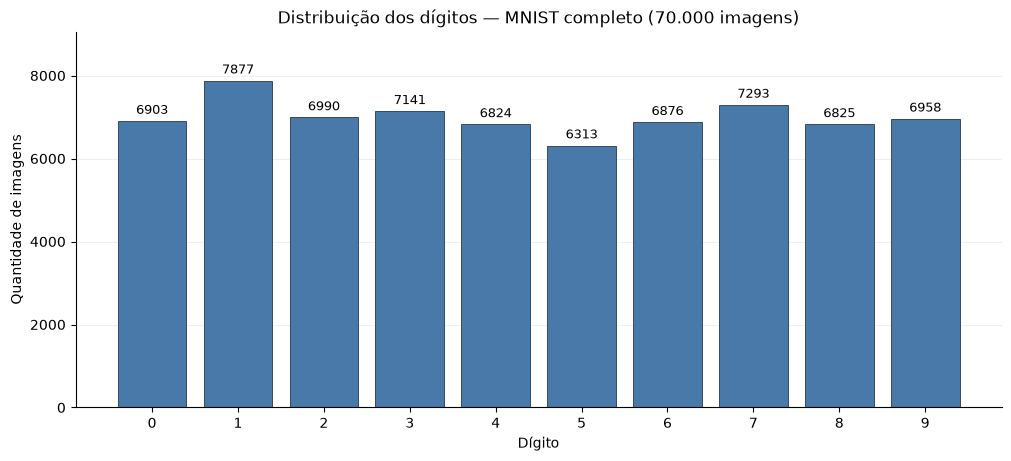

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
barras = ax.bar(contagens.index, contagens.values, color="#4879A8", edgecolor="#26384A", linewidth=0.6)
ax.bar_label(barras, padding=3, fontsize=9)
ax.set(title="Distribuição dos dígitos — MNIST completo (70.000 imagens)",
       xlabel="Dígito", ylabel="Quantidade de imagens",
       xticks=np.arange(10), ylim=(0, contagens.max() * 1.15))
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
fig.savefig(FIGURES_DIR / "distribuicao_classes.png", dpi=150)
plt.show()

### Exemplos de cada classe

A grade mostra a primeira ocorrência de cada dígito na base, com escala de intensidade idêntica em todos os painéis.

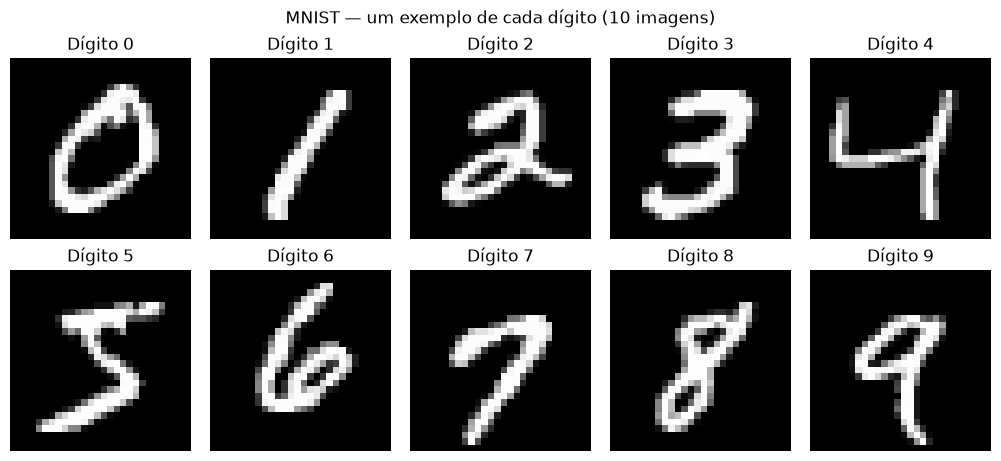

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5), layout="constrained")

for digito, ax in zip(range(10), axes.flat):
    indice = np.flatnonzero(y == digito)[0]
    ax.imshow(X[indice].reshape(28, 28), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(f"Dígito {y[indice]}")
    ax.axis("off")

fig.suptitle("MNIST — um exemplo de cada dígito (10 imagens)")
fig.savefig(FIGURES_DIR / "exemplos_digitos.png", dpi=150)
plt.show()

### Imagem e representação vetorial

Cada imagem contém 28 × 28 = 784 intensidades: 0 indica preto, 255 indica branco e os valores intermediários representam tons de cinza. O OpenML já fornece cada imagem achatada em uma linha de `X`. A operação `reshape(28, 28)` recupera a disposição bidimensional preservando a ordem dos pixels.

Forma do vetor: (784,)
Forma da imagem: (28, 28)
A transformação preservou todos os pixels: True


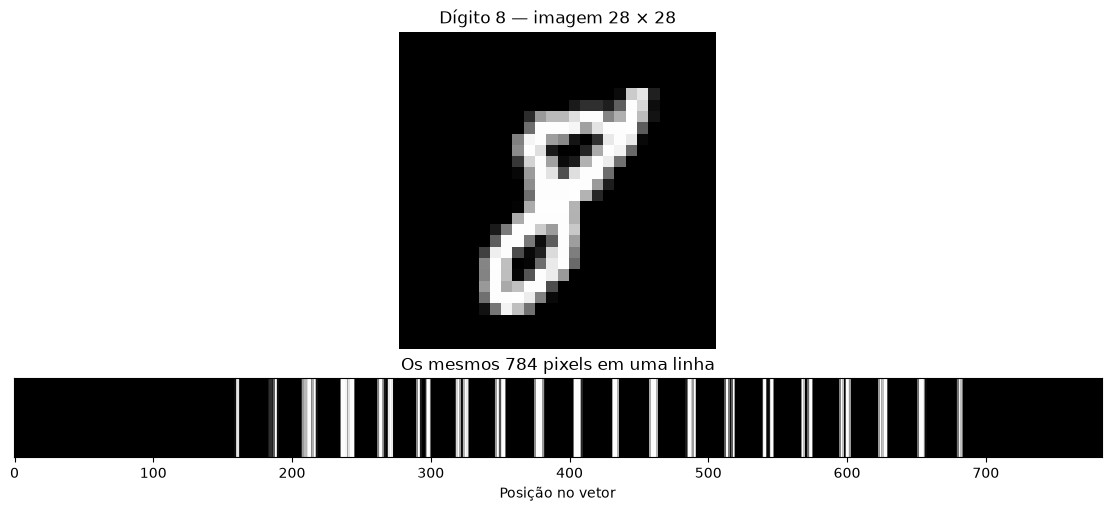

In [9]:
indice_exemplo = np.flatnonzero(y == 8)[0]
vetor = X[indice_exemplo]
imagem = vetor.reshape(28, 28)

assert np.array_equal(imagem.reshape(-1), vetor)
print("Forma do vetor:", vetor.shape)
print("Forma da imagem:", imagem.shape)
print("A transformação preservou todos os pixels:", np.array_equal(imagem.reshape(-1), vetor))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), height_ratios=[4, 1], layout="constrained")
axes[0].imshow(imagem, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title(f"Dígito {y[indice_exemplo]} — imagem 28 × 28")
axes[0].axis("off")
axes[1].imshow(vetor.reshape(1, 784), cmap="gray", vmin=0, vmax=255, aspect="auto", interpolation="nearest")
axes[1].set(title="Os mesmos 784 pixels em uma linha", xlabel="Posição no vetor", yticks=[])
fig.savefig(FIGURES_DIR / "imagem_e_vetor.png", dpi=150)
plt.show()

### Síntese da análise exploratória

A base contém 70.000 imagens, com 784 intensidades inteiras entre 0 e 255 por imagem e nenhum valor ausente em `X`. As dez classes estão presentes e têm frequências próximas, mas não iguais: o dígito 1 é o mais frequente (7.877; 11,25%) e o 5 é o menos frequente (6.313; 9,02%). A transformação entre vetor e imagem preservou os pixels. Esses resultados descrevem os dados; a avaliação preditiva será realizada após a divisão em conjuntos independentes.

## 3. Divisão dos dados e normalização

Adotamos uma divisão aleatória estratificada das 70.000 imagens do OpenML: **60% treino, 10% validação, 10% calibração e 20% teste**, com semente 42. Esse protocolo é próprio do projeto e não corresponde à divisão oficial do MNIST em 60.000/10.000 imagens.

O treino ajustará os modelos; a validação selecionará configurações pelo F1 ponderado; a calibração será reservada para ajustar as probabilidades do modelo escolhido; o teste fornecerá a avaliação final. As mesmas partições serão usadas nas comparações. Nenhuma escolha de modelo deve usar os resultados do teste.

A estratificação deve preservar aproximadamente a frequência de cada dígito. Dividimos os índices das linhas para manter a correspondência entre imagens e rótulos e verificar cobertura e ausência de sobreposição.

In [10]:
indices = np.arange(len(y))
indices_restantes, indices_teste = train_test_split(
    indices, test_size=14_000, stratify=y, random_state=RANDOM_STATE,
)
indices_treino, indices_reserva = train_test_split(
    indices_restantes, test_size=14_000,
    stratify=y[indices_restantes], random_state=RANDOM_STATE,
)
indices_validacao, indices_calibracao = train_test_split(
    indices_reserva, test_size=7_000,
    stratify=y[indices_reserva], random_state=RANDOM_STATE,
)

particoes = {
    "Treino": indices_treino,
    "Validação": indices_validacao,
    "Calibração": indices_calibracao,
    "Teste": indices_teste,
}
indices_reunidos = np.concatenate(list(particoes.values()))
assert np.array_equal(np.sort(indices_reunidos), indices)
assert [len(idx) for idx in particoes.values()] == [42_000, 7_000, 7_000, 14_000]

pd.DataFrame({
    "Imagens": {nome: len(idx) for nome, idx in particoes.items()},
    "Percentual (%)": {nome: len(idx) / len(y) * 100 for nome, idx in particoes.items()},
})

,Imagens,Percentual (%)
Treino,42000,60.0
Validação,7000,10.0
Calibração,7000,10.0
Teste,14000,20.0


### Verificação da estratificação

Comparamos a proporção de cada dígito em cada conjunto com sua proporção na base integral. Pequenas diferenças são esperadas porque as quantidades de imagens precisam ser inteiras. O desvio é expresso em pontos percentuais.

In [11]:
contagens_particoes = pd.DataFrame({
    nome: np.bincount(y[idx], minlength=10)
    for nome, idx in particoes.items()
}, index=pd.Index(range(10), name="Dígito"))
proporcoes_particoes = contagens_particoes.div(contagens_particoes.sum()) * 100
proporcoes_base = np.bincount(y, minlength=10) / len(y) * 100
maior_desvio_pp = proporcoes_particoes.sub(proporcoes_base, axis=0).abs().max().max()

assert (contagens_particoes > 0).all().all()
assert np.array_equal(contagens_particoes.sum(axis=1).to_numpy(), np.bincount(y))
print(f"Maior desvio em relação à base: {maior_desvio_pp:.4f} ponto percentual")
proporcoes_particoes.round(3)

Maior desvio em relação à base: 0.0100 ponto percentual


,Treino,Validação,Calibração,Teste
Dígito,,,,
0,9.860,9.871,9.857,9.864
1,11.255,11.257,11.243,11.250
2,9.986,9.986,9.986,9.986
3,10.202,10.200,10.200,10.200
4,9.748,9.743,9.757,9.750
5,9.019,9.014,9.014,9.021
6,9.824,9.814,9.829,9.821
7,10.417,10.414,10.429,10.421
8,9.750,9.757,9.743,9.750


**Conclusão da divisão.** Foram obtidas 42.000 imagens de treino, 7.000 de validação, 7.000 de calibração e 14.000 de teste, conforme planejado. A verificação dos índices confirmou que cada linha original pertence a exatamente uma partição. As dez classes estão presentes em todos os conjuntos; o maior desvio de frequência em relação à base foi de 0,0100 ponto percentual, compatível com o arredondamento de quantidades inteiras. A divisão preservou a composição das classes. Essa checagem garante separação por linha; não é uma auditoria de imagens duplicadas na fonte.

### Normalização das intensidades

Cada pixel será convertido para `float32` e dividido por 255, passando da escala [0, 255] para [0, 1]. O divisor é fixado pela representação dos pixels e não é estimado a partir dos dados. Assim, essa transformação não aprende informações da validação, da calibração ou do teste.

Mantemos 784 atributos por imagem para KNN, Random Forest e MLP. Na etapa da CNN, a mesma informação poderá ser reorganizada em 28 × 28 × 1. Os rótulos permanecem inteiros de 0 a 9.

In [12]:
X_treino = X[indices_treino].astype(np.float32) / np.float32(255)
X_validacao = X[indices_validacao].astype(np.float32) / np.float32(255)
X_calibracao = X[indices_calibracao].astype(np.float32) / np.float32(255)
X_teste = X[indices_teste].astype(np.float32) / np.float32(255)

y_treino = y[indices_treino]
y_validacao = y[indices_validacao]
y_calibracao = y[indices_calibracao]
y_teste = y[indices_teste]

conjuntos = {
    "Treino": (X_treino, y_treino),
    "Validação": (X_validacao, y_validacao),
    "Calibração": (X_calibracao, y_calibracao),
    "Teste": (X_teste, y_teste),
}
diagnosticos = []
for nome, (pixels, rotulos) in conjuntos.items():
    assert pixels.shape == (len(rotulos), 784)
    assert pixels.dtype == np.float32
    assert np.isfinite(pixels).all()
    assert 0 <= pixels.min() <= pixels.max() <= 1
    assert np.array_equal(rotulos, y[particoes[nome]])
    diagnosticos.append({
        "Conjunto": nome, "Forma de X": str(pixels.shape),
        "Forma de y": str(rotulos.shape), "Tipo de X": str(pixels.dtype),
        "Mínimo": float(pixels.min()), "Máximo": float(pixels.max()),
    })

pd.DataFrame(diagnosticos).set_index("Conjunto")

,Forma de X,Forma de y,Tipo de X,Mínimo,Máximo
Conjunto,,,,,
Treino,"(42000, 784)","(42000,)",float32,0.0,1.0
Validação,"(7000, 784)","(7000,)",float32,0.0,1.0
Calibração,"(7000, 784)","(7000,)",float32,0.0,1.0
Teste,"(14000, 784)","(14000,)",float32,0.0,1.0


**Conclusão da normalização.** As quatro matrizes passaram a `float32`, com intensidades mínimas de 0 e máximas de 1, sem valores não finitos. Foram preservados os 784 atributos por imagem e o alinhamento entre imagens e rótulos. O resultado corresponde à escala esperada e prepara as entradas para o treinamento. A normalização não altera as classes nem demonstra ganho preditivo; o desempenho será medido nas próximas etapas.

### Auditoria de imagens exatamente duplicadas

Comparamos os 784 pixels originais de cada imagem, convertidos sem perda para bytes (`uint8`). A igualdade considera todo o conteúdo da imagem, independentemente do rótulo. Esperamos não encontrar cópias exatas que possam atravessar partições. Esta verificação não detecta imagens apenas semelhantes.

In [13]:
imagens_unicas = {linha.astype(np.uint8).tobytes() for linha in X}
repeticoes_exatas = len(X) - len(imagens_unicas)
print(f"Imagens únicas: {len(imagens_unicas):,}")
print(f"Repetições exatas além da primeira ocorrência: {repeticoes_exatas}")
assert repeticoes_exatas == 0, "Revisar a divisão antes de treinar: existem imagens repetidas."
del imagens_unicas

Imagens únicas: 70,000
Repetições exatas além da primeira ocorrência: 0


**Conclusão da auditoria.** Foram identificadas 70.000 imagens distintas e nenhuma repetição exata. Portanto, não há cópias idênticas entre as partições. O resultado atende à expectativa desta checagem e complementa a verificação de índices; semelhanças visuais e outras dependências entre exemplos não foram auditadas.

## 4. Treinamento e seleção na validação

### 4.1. KNN — vizinhos mais próximos

Comparamos quatro configurações: 3 ou 5 vizinhos, com voto uniforme ou ponderado pelo inverso da distância. Usamos distância euclidiana (`p=2`) e busca exata (`algorithm="brute"`), adequada à representação com 784 atributos.

O critério de seleção é o F1 ponderado na validação. Em empate exato, priorizamos voto uniforme e, depois, menos vizinhos. A acurácia é apresentada como medida complementar. Os tempos de ajuste e predição são medidos separadamente, pois o KNN armazena os exemplos no ajuste e concentra seu trabalho na consulta aos vizinhos. Não usamos calibração ou teste nesta seleção.

In [14]:
resultados_knn = []
modelos_knn = {}

for n_vizinhos in (3, 5):
    for pesos in ("uniform", "distance"):
        modelo = KNeighborsClassifier(
            n_neighbors=n_vizinhos, weights=pesos,
            metric="minkowski", p=2, algorithm="brute", n_jobs=-1,
        )
        inicio = perf_counter()
        modelo.fit(X_treino, y_treino)
        tempo_ajuste = perf_counter() - inicio

        inicio = perf_counter()
        previsoes = modelo.predict(X_validacao)
        tempo_predicao = perf_counter() - inicio

        modelos_knn[(n_vizinhos, pesos)] = modelo
        resultados_knn.append({
            "n_neighbors": n_vizinhos,
            "weights": pesos,
            "F1 ponderado": f1_score(y_validacao, previsoes, average="weighted", zero_division=0),
            "Acurácia": accuracy_score(y_validacao, previsoes),
            "Tempo de ajuste (s)": tempo_ajuste,
            "Tempo de predição (s)": tempo_predicao,
        })
        print(f"Concluído: k={n_vizinhos}, weights={pesos}")

tabela_knn = pd.DataFrame(resultados_knn)
tabela_knn["ordem_pesos"] = tabela_knn["weights"].map({"uniform": 0, "distance": 1})
tabela_knn = tabela_knn.sort_values(
    ["F1 ponderado", "ordem_pesos", "n_neighbors"],
    ascending=[False, True, True],
).drop(columns="ordem_pesos").reset_index(drop=True)

melhor_configuracao_knn = tabela_knn.iloc[0]
melhor_knn = modelos_knn[(int(melhor_configuracao_knn["n_neighbors"]), melhor_configuracao_knn["weights"])]
assert np.array_equal(melhor_knn.classes_, np.arange(10))
assert len(tabela_knn) == 4
assert tabela_knn[["F1 ponderado", "Acurácia"]].ge(0).all().all()
assert tabela_knn[["F1 ponderado", "Acurácia"]].le(1).all().all()
tabela_knn.round(6)

Concluído: k=3, weights=uniform


Concluído: k=3, weights=distance


Concluído: k=5, weights=uniform


Concluído: k=5, weights=distance


,n_neighbors,weights,F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,3,distance,0.969526,0.969571,0.005082,1.297071
1,3,uniform,0.969511,0.969571,0.005132,1.416328
2,5,distance,0.968680,0.968714,0.005623,1.210046
3,5,uniform,0.967361,0.967429,0.005403,1.259577


**Conclusão do KNN.** A configuração com 3 vizinhos e pesos por distância obteve o maior F1 ponderado de validação (0,969526), com acurácia de 0,969571: 6.787 acertos entre 7.000 imagens. O voto uniforme com 3 vizinhos atingiu a mesma acurácia e F1 de 0,969511. A diferença de aproximadamente 0,000015 em F1 é muito pequena; a seleção segue o critério previamente definido, mas não demonstra superioridade estatística. A igualdade da acurácia com F1 diferente é possível porque os erros se distribuem de forma diferente entre as classes.

As configurações com 5 vizinhos tiveram F1 inferior nesta validação. Esperávamos que variar a quantidade de vizinhos e os pesos alterasse a decisão local; encontramos uma vantagem discreta de 3 vizinhos. Os tempos registrados na tabela mostram que o ajuste foi muito mais rápido que a predição, coerente com a concentração do trabalho do KNN na consulta. Esses tempos dependem do equipamento e não constituem um benchmark controlado.

O estimador selecionado permanece em `melhor_knn` para comparação posterior. Os resultados são de validação; a avaliação final no teste ainda não foi realizada.

### 4.2. Random Forest — conjunto de árvores

Comparamos 100 ou 200 árvores com profundidade máxima 20 ou sem limite explícito (`None`). Cada árvore utiliza uma amostra de treino com reposição (`bootstrap=True`) e considera um subconjunto aleatório de atributos em cada divisão (`max_features="sqrt"`). A semente 42 torna o experimento reproduzível nas mesmas condições.

Selecionamos pelo F1 ponderado na mesma validação usada pelo KNN. Em empate exato, preferimos profundidade limitada a 20 e, depois, menos árvores. Esperamos que aumentar a capacidade possa alterar o desempenho, sem garantir melhoria; os tempos de ajuste e predição serão registrados para avaliar o custo observado. Calibração e teste permanecem reservados.

In [15]:
resultados_rf = []
modelos_rf = {}

for n_arvores in (100, 200):
    for profundidade in (20, None):
        modelo = RandomForestClassifier(
            n_estimators=n_arvores, max_depth=profundidade,
            max_features="sqrt", bootstrap=True,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
        inicio = perf_counter()
        modelo.fit(X_treino, y_treino)
        tempo_ajuste = perf_counter() - inicio

        inicio = perf_counter()
        previsoes = modelo.predict(X_validacao)
        tempo_predicao = perf_counter() - inicio

        rotulo_profundidade = "20" if profundidade == 20 else "Sem limite"
        modelos_rf[(n_arvores, rotulo_profundidade)] = modelo
        resultados_rf.append({
            "n_estimators": n_arvores,
            "max_depth": rotulo_profundidade,
            "F1 ponderado": f1_score(y_validacao, previsoes, average="weighted", zero_division=0),
            "Acurácia": accuracy_score(y_validacao, previsoes),
            "Tempo de ajuste (s)": tempo_ajuste,
            "Tempo de predição (s)": tempo_predicao,
        })
        print(f"Concluído: árvores={n_arvores}, profundidade={rotulo_profundidade}")

tabela_rf = pd.DataFrame(resultados_rf)
tabela_rf["ordem_profundidade"] = tabela_rf["max_depth"].map({"20": 0, "Sem limite": 1})
tabela_rf = tabela_rf.sort_values(
    ["F1 ponderado", "ordem_profundidade", "n_estimators"],
    ascending=[False, True, True],
).drop(columns="ordem_profundidade").reset_index(drop=True)

melhor_configuracao_rf = tabela_rf.iloc[0]
melhor_rf = modelos_rf[(int(melhor_configuracao_rf["n_estimators"]), melhor_configuracao_rf["max_depth"])]
assert np.array_equal(melhor_rf.classes_, np.arange(10))
assert len(tabela_rf) == 4
assert tabela_rf[["F1 ponderado", "Acurácia"]].ge(0).all().all()
assert tabela_rf[["F1 ponderado", "Acurácia"]].le(1).all().all()
tabela_rf.round(6)

Concluído: árvores=100, profundidade=20


Concluído: árvores=100, profundidade=Sem limite


Concluído: árvores=200, profundidade=20


Concluído: árvores=200, profundidade=Sem limite


,n_estimators,max_depth,F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,200,Sem limite,0.967215,0.967286,4.362422,0.061891
1,100,Sem limite,0.966789,0.966857,2.122605,0.027148
2,200,20,0.965802,0.965857,3.976409,0.048465
3,100,20,0.965385,0.965429,2.077866,0.039684


**Conclusão da Random Forest.** A configuração com 200 árvores e sem limite explícito de profundidade obteve o maior F1 ponderado na validação (0,967215), com acurácia de 0,967286: 6.771 acertos entre 7.000 imagens. Nas quatro configurações avaliadas, aumentar de 100 para 200 árvores melhorou discretamente o F1, assim como retirar o limite de profundidade para uma mesma quantidade de árvores. Esse resultado é compatível com um benefício de maior capacidade nesta validação; não prova ausência de sobreajuste nem garante a mesma ordenação em outras amostras.

O KNN selecionado teve F1 de 0,969526 e 16 acertos a mais. Os tempos de predição registrados nas tabelas foram menores para a Random Forest. Portanto, o KNN apresentou melhor F1 nesta comparação, enquanto a Random Forest apresentou menor tempo de predição observado. Os tempos dependem do equipamento, paralelismo e condições de execução; não constituem um benchmark controlado.

O estimador selecionado permanece em `melhor_rf`. A escolha entre famílias continua pendente até a avaliação das redes neurais na validação; o teste ainda não foi usado.

### 4.3. MLP em Keras — rede totalmente conectada

A entrada contém 784 pixels normalizados. Comparamos duas arquiteturas ocultas, (128, 64) e (256, 128), com ReLU e regularização L2 de 0,0001 ou 0,001 nas duas camadas ocultas. A saída contém dez neurônios com softmax, na ordem dos dígitos 0 a 9.

Usamos Adam com taxa 0,001, lotes de 64 imagens e no máximo 30 épocas. A função objetivo é a entropia cruzada categórica esparsa, acrescida da penalização L2. O `EarlyStopping` acompanha `val_loss`, com paciência de 3 épocas, e restaura os pesos da melhor época segundo essa perda. Entre as quatro configurações, selecionamos pelo F1 ponderado na validação; em empate exato, preferimos menos parâmetros e, depois, maior L2.

A semente é reiniciada em 42 antes de cada configuração, com operações determinísticas habilitadas. A reprodução pressupõe o mesmo ambiente; uma única semente não mede a variabilidade do treinamento. Referências: [EarlyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) e [determinismo no TensorFlow](https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_op_determinism).

In [16]:
tf.keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()


def criar_mlp(camadas, coeficiente_l2):
    modelo = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(camadas[0], activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(coeficiente_l2)),
        tf.keras.layers.Dense(camadas[1], activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(coeficiente_l2)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo

In [17]:
resultados_mlp = []
modelos_mlp = {}
historicos_mlp = {}

for camadas in ((128, 64), (256, 128)):
    for coeficiente_l2 in (0.0001, 0.001):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(RANDOM_STATE)
        modelo = criar_mlp(camadas, coeficiente_l2)
        parada = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, mode="min", restore_best_weights=True,
        )
        inicio = perf_counter()
        historico = modelo.fit(
            X_treino, y_treino, validation_data=(X_validacao, y_validacao),
            epochs=30, batch_size=64, shuffle=True, callbacks=[parada], verbose=0,
        )
        tempo_ajuste = perf_counter() - inicio

        inicio = perf_counter()
        probabilidades = modelo.predict(X_validacao, batch_size=256, verbose=0)
        tempo_predicao = perf_counter() - inicio
        assert probabilidades.shape == (len(y_validacao), 10)
        assert np.isfinite(probabilidades).all()
        assert (probabilidades >= 0).all() and (probabilidades <= 1).all()
        assert np.allclose(probabilidades.sum(axis=1), 1, atol=1e-5)
        previsoes = probabilidades.argmax(axis=1)

        chave = (camadas, coeficiente_l2)
        modelos_mlp[chave] = modelo
        historicos_mlp[chave] = historico.history
        resultados_mlp.append({
            "Camadas": str(camadas), "L2": coeficiente_l2,
            "Parâmetros": modelo.count_params(),
            "Épocas executadas": len(historico.history["loss"]),
            "Melhor época (val_loss)": int(np.argmin(historico.history["val_loss"]) + 1),
            "F1 ponderado": f1_score(y_validacao, previsoes, average="weighted", zero_division=0),
            "Acurácia": accuracy_score(y_validacao, previsoes),
            "Tempo de ajuste (s)": tempo_ajuste,
            "Tempo de predição (s)": tempo_predicao,
        })
        print(f"Concluído: camadas={camadas}, L2={coeficiente_l2}, "
              f"épocas={len(historico.history['loss'])}", flush=True)

tabela_mlp = pd.DataFrame(resultados_mlp).sort_values(
    ["F1 ponderado", "Parâmetros", "L2"], ascending=[False, True, False],
).reset_index(drop=True)
melhor_configuracao_mlp = tabela_mlp.iloc[0]
melhor_chave_mlp = next(
    chave for chave in modelos_mlp
    if str(chave[0]) == melhor_configuracao_mlp["Camadas"]
    and chave[1] == melhor_configuracao_mlp["L2"]
)
melhor_mlp = modelos_mlp[melhor_chave_mlp]
melhor_historico_mlp = historicos_mlp[melhor_chave_mlp]
assert len(tabela_mlp) == 4
tabela_mlp.round(6)

Concluído: camadas=(128, 64), L2=0.0001, épocas=9


Concluído: camadas=(128, 64), L2=0.001, épocas=28


Concluído: camadas=(256, 128), L2=0.0001, épocas=9


Concluído: camadas=(256, 128), L2=0.001, épocas=26


,Camadas,L2,Parâmetros,Épocas executadas,Melhor época (val_loss),F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,"(256, 128)",0.0001,235146,9,6,0.977409,0.977429,6.436472,0.063184
1,"(256, 128)",0.0010,235146,26,23,0.973270,0.973286,18.376029,0.064683
2,"(128, 64)",0.0010,109386,28,25,0.972877,0.972857,12.692333,0.055125
3,"(128, 64)",0.0001,109386,9,6,0.970552,0.970571,4.593974,0.062425


### Evolução do treinamento da MLP selecionada

As curvas mostram perda e acurácia por época. A perda inclui a penalização L2; a linha vertical identifica a época cujos pesos foram restaurados. As medidas de treino são acumuladas durante as atualizações dos pesos, enquanto a validação é calculada ao final da época. Portanto, as duas curvas não são medidas no mesmo instante do ajuste.

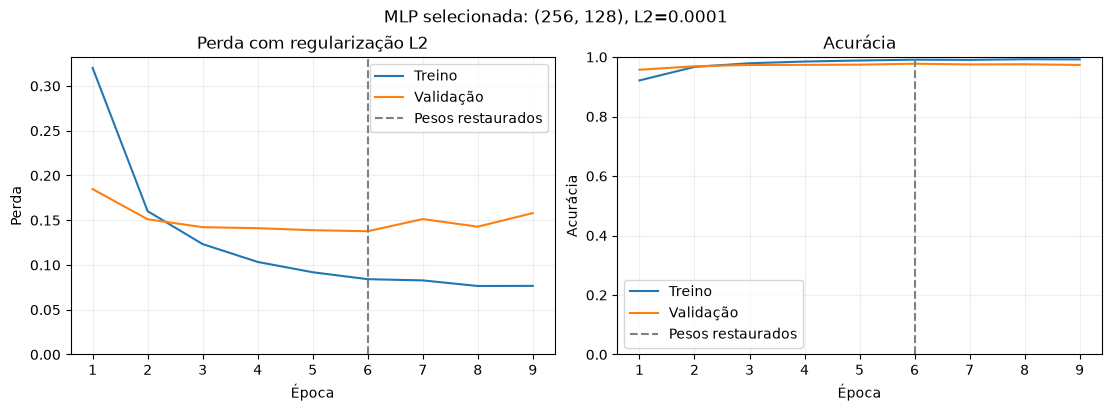

MLP selecionada salva em artifacts/melhor_mlp.keras


In [18]:
epocas = np.arange(1, len(melhor_historico_mlp["loss"]) + 1)
melhor_epoca = int(melhor_configuracao_mlp["Melhor época (val_loss)"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metrica, titulo, rotulo in zip(
    axes, ("loss", "accuracy"), ("Perda com regularização L2", "Acurácia"), ("Perda", "Acurácia"),
):
    ax.plot(epocas, melhor_historico_mlp[metrica], label="Treino")
    ax.plot(epocas, melhor_historico_mlp[f"val_{metrica}"], label="Validação")
    ax.axvline(melhor_epoca, color="gray", linestyle="--", label="Pesos restaurados")
    ax.set(title=titulo, xlabel="Época", ylabel=rotulo)
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(0, 1)
fig.suptitle(f"MLP selecionada: {melhor_chave_mlp[0]}, L2={melhor_chave_mlp[1]}")
fig.savefig(FIGURES_DIR / "curvas_mlp.png", dpi=150)
plt.show()

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
melhor_mlp.save(ARTIFACTS_DIR / "melhor_mlp.keras")
tabela_mlp.to_json(ARTIFACTS_DIR / "resultados_mlp.json", orient="records", indent=2)
print("MLP selecionada salva em artifacts/melhor_mlp.keras")

**Conclusão da MLP.** A arquitetura (256, 128), com L2 de 0,0001, obteve o maior F1 ponderado na validação (0,977409) e acurácia de 0,977429: 6.842 acertos entre 7.000 imagens, com 158 erros. São 55 acertos a mais que o KNN selecionado nesta mesma amostra. Esse resultado coloca a MLP à frente dos três modelos principais na validação; a CNN ainda será avaliada e não houve consulta ao desempenho no teste.

A configuração selecionada possui 235.146 parâmetros, executou nove épocas e restaurou os pesos da sexta. A curva de perda de treino continuou diminuindo, enquanto a perda de validação não melhorou nas três épocas seguintes. Esse padrão é compatível com início de sobreajuste e justifica a parada adotada. A perda inclui L2 e não deve ser interpretada como taxa de erro.

Esperávamos que tamanho da rede e regularização influenciassem o desempenho. O efeito observado dependeu da arquitetura: L2 de 0,001 melhorou o F1 da rede menor, mas reduziu o da maior, em comparação com 0,0001. Portanto, aumentar a regularização não garantiu melhoria. As quatro configurações terminaram antes do limite de 30 épocas. As probabilidades verificadas foram finitas, não negativas e somaram aproximadamente 1 por imagem; essa propriedade não comprova calibração.

O modelo selecionado permanece em `melhor_mlp` e foi salvo em `artifacts/melhor_mlp.keras`, diretório local ignorado pelo Git. As curvas documentam o treinamento. As comparações refletem uma divisão e uma semente; ainda não estimam a variabilidade do ajuste.

### 4.4. CNN — rede convolucional

Acrescentamos uma arquitetura fixa e pequena, sem busca de hiperparâmetros: duas convoluções 3 × 3 com 32 e 64 filtros, cada uma seguida de max pooling 2 × 2, e uma camada densa de 64 neurônios antes da saída softmax. Usamos convoluções com `padding="valid"`, ReLU e L2 de 0,0001 na camada densa oculta.

As mesmas imagens já normalizadas são reorganizadas em 28 × 28 × 1, preservando pixels, rótulos e partições. A expectativa é que filtros locais com pesos compartilhados aproveitem a estrutura espacial dos dígitos; a comparação verificará se isso melhora o F1 nesta validação. Mantemos Adam a 0,001, lotes de 64, até 30 épocas e parada antecipada pela perda de validação com paciência 3 e restauração dos melhores pesos. Não usamos aumento artificial de dados.

Referência: [Conv2D no TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D).

In [19]:
X_treino_cnn = X_treino.reshape(-1, 28, 28, 1)
X_validacao_cnn = X_validacao.reshape(-1, 28, 28, 1)
assert np.array_equal(X_treino_cnn.reshape(-1, 784), X_treino)
assert np.array_equal(X_validacao_cnn.reshape(-1, 784), X_validacao)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)
modelo_cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="valid", name="conv_1"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool_1"),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="valid", name="conv_2"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool_2"),
    tf.keras.layers.Flatten(name="achatamento"),
    tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001), name="densa"),
    tf.keras.layers.Dense(10, activation="softmax", name="saida"),
], name="cnn_mnist")
modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"],
)
modelo_cnn.summary()

Model: "cnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ achatamento (Flatten)           │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
parada_cnn = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, mode="min", restore_best_weights=True,
)
inicio = perf_counter()
historico_cnn = modelo_cnn.fit(
    X_treino_cnn, y_treino, validation_data=(X_validacao_cnn, y_validacao),
    epochs=30, batch_size=64, shuffle=True, callbacks=[parada_cnn], verbose=0,
)
tempo_ajuste_cnn = perf_counter() - inicio

inicio = perf_counter()
probabilidades_cnn_validacao = modelo_cnn.predict(X_validacao_cnn, batch_size=256, verbose=0)
tempo_predicao_cnn = perf_counter() - inicio
assert probabilidades_cnn_validacao.shape == (len(y_validacao), 10)
assert np.isfinite(probabilidades_cnn_validacao).all()
assert (probabilidades_cnn_validacao >= 0).all() and (probabilidades_cnn_validacao <= 1).all()
assert np.allclose(probabilidades_cnn_validacao.sum(axis=1), 1, atol=1e-5)
previsoes_cnn_validacao = probabilidades_cnn_validacao.argmax(axis=1)

resultado_cnn = {
    "Modelo": "CNN", "Parâmetros": modelo_cnn.count_params(),
    "Épocas executadas": len(historico_cnn.history["loss"]),
    "Melhor época (val_loss)": int(np.argmin(historico_cnn.history["val_loss"]) + 1),
    "F1 ponderado": f1_score(y_validacao, previsoes_cnn_validacao, average="weighted", zero_division=0),
    "Acurácia": accuracy_score(y_validacao, previsoes_cnn_validacao),
    "Tempo de ajuste (s)": tempo_ajuste_cnn,
    "Tempo de predição (s)": tempo_predicao_cnn,
}
modelo_cnn.save(ARTIFACTS_DIR / "cnn.keras")
pd.DataFrame([resultado_cnn]).to_json(ARTIFACTS_DIR / "resultado_cnn.json", orient="records", indent=2)
pd.DataFrame([resultado_cnn]).round(6)

,Modelo,Parâmetros,Épocas executadas,Melhor época (val_loss),F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,CNN,121930,5,2,0.982846,0.982857,19.895016,0.219383


### Curvas da CNN

A perda inclui a penalização L2. A linha vertical indica a época restaurada; as curvas completas incluem as épocas posteriores que acionaram a parada, quando aplicável.

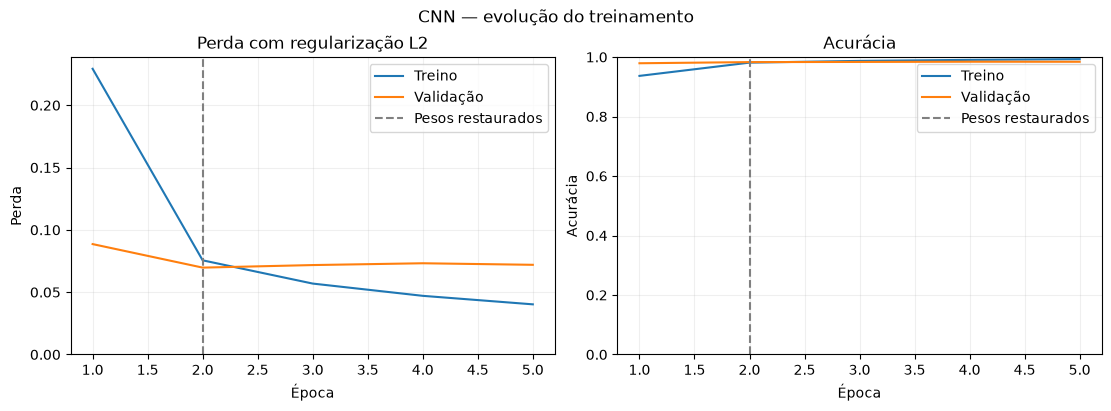

In [21]:
epocas_cnn = np.arange(1, len(historico_cnn.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metrica, titulo, rotulo in zip(
    axes, ("loss", "accuracy"), ("Perda com regularização L2", "Acurácia"), ("Perda", "Acurácia"),
):
    ax.plot(epocas_cnn, historico_cnn.history[metrica], label="Treino")
    ax.plot(epocas_cnn, historico_cnn.history[f"val_{metrica}"], label="Validação")
    ax.axvline(resultado_cnn["Melhor época (val_loss)"], color="gray", linestyle="--", label="Pesos restaurados")
    ax.set(title=titulo, xlabel="Época", ylabel=rotulo)
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(0, 1)
fig.suptitle("CNN — evolução do treinamento")
fig.savefig(FIGURES_DIR / "curvas_cnn.png", dpi=150)
plt.show()

**Conclusão da CNN.** A arquitetura fixa obteve F1 ponderado de 0,982846 e acurácia de 0,982857 na validação: 6.880 acertos entre 7.000 imagens, com 120 erros. Foram executadas cinco épocas e restaurados os pesos da segunda, que apresentou a menor perda de validação. Nas três épocas posteriores, a perda de treino continuou diminuindo, mas a de validação não superou o mínimo anterior; a parada seguiu o critério estabelecido.

O resultado foi superior ao da MLP selecionada nesta amostra, com 38 acertos a mais, sendo compatível com a expectativa de benefício da estrutura convolucional para imagens. A comparação não isola causalmente o efeito da convolução: arquiteturas, quantidade de parâmetros e processos de ajuste são diferentes. A CNN tem 121.930 parâmetros, contra 235.146 da MLP selecionada; menos parâmetros não implica automaticamente menor tempo de execução.

As verificações confirmaram preservação dos pixels na reorganização e probabilidades finitas, não negativas e normalizadas. O modelo foi salvo localmente em `artifacts/cnn.keras`.

### Diagramas das arquiteturas utilizadas

Os diagramas são gerados com [VisualKeras](https://github.com/paulgavrikov/visualkeras) a partir dos modelos ajustados. Os rótulos indicam tipos de camada e dimensões de saída por imagem, sem o eixo de lote. A entrada aparece no título; as tabelas incluem entrada e parâmetros. Os blocos são esquemáticos e têm dimensões visuais limitadas para legibilidade, não uma escala proporcional exata.

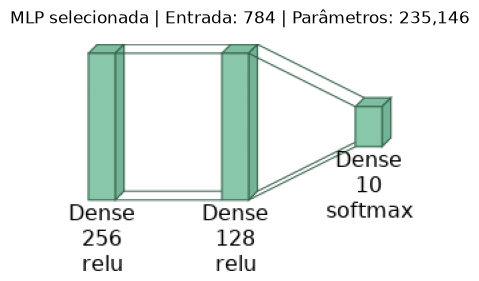

,Camada,Saída por imagem,Parâmetros
0,Entrada,784,0
1,Dense,"(256,)",200960
2,Dense,"(128,)",32896
3,Dense,"(10,)",1290


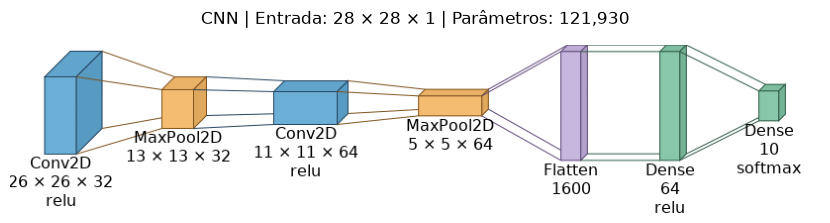

,Camada,Saída por imagem,Parâmetros
0,Entrada,28 × 28 × 1,0
1,Conv2D,"(26, 26, 32)",320
2,MaxPooling2D,"(13, 13, 32)",0
3,Conv2D,"(11, 11, 64)",18496
4,MaxPooling2D,"(5, 5, 64)",0
5,Flatten,"(1600,)",0
6,Dense,"(64,)",102464
7,Dense,"(10,)",650


In [22]:
def rotulo_camada(indice, camada):
    dimensoes = " × ".join(str(int(d)) for d in camada.output.shape[1:])
    nome = type(camada).__name__
    if nome == "MaxPooling2D":
        nome = "MaxPool2D"
    ativacao = getattr(camada, "activation", None)
    sufixo = f"\n{ativacao.__name__}" if ativacao is not None else ""
    return f"{nome}\n{dimensoes}{sufixo}", False


def diagrama_arquitetura(modelo, nome, arquivo):
    # VisualKeras 0.2 requer este metadado, ausente nas camadas do Keras 3.
    for camada in modelo.layers:
        camada.output_shape = tuple(camada.output.shape)
    fonte = ImageFont.truetype(font_manager.findfont("DejaVu Sans"), 16)
    cores = {
        tf.keras.layers.Conv2D: {"fill": "#6BAED6", "outline": "#26455F"},
        tf.keras.layers.MaxPooling2D: {"fill": "#F4BC71", "outline": "#80531E"},
        tf.keras.layers.Flatten: {"fill": "#C7B6DE", "outline": "#5F497A"},
        tf.keras.layers.Dense: {"fill": "#88C7AA", "outline": "#315C47"},
    }
    imagem = visualkeras.layered_view(
        modelo, font=fonte, text_callable=rotulo_camada,
        color_map=cores, spacing=80, padding=35,
        max_xy=110, max_z=90, scale_xy=3, scale_z=1,
        one_dim_orientation="y", legend=False, legend_text_spacing_offset=0,
    )
    fig, ax = plt.subplots(figsize=(max(8, imagem.width / 100), imagem.height / 100 + 1), layout="constrained")
    ax.imshow(imagem)
    ax.axis("off")
    entrada = " × ".join(str(int(d)) for d in modelo.input_shape[1:])
    ax.set_title(f"{nome} | Entrada: {entrada} | Parâmetros: {modelo.count_params():,}", pad=15)
    fig.savefig(FIGURES_DIR / arquivo, dpi=150)
    plt.show()
    linhas = [{"Camada": "Entrada", "Saída por imagem": entrada, "Parâmetros": 0}]
    for camada in modelo.layers:
        linhas.append({
            "Camada": type(camada).__name__,
            "Saída por imagem": str(tuple(camada.output.shape[1:])),
            "Parâmetros": camada.count_params(),
        })
    tabela = pd.DataFrame(linhas)
    assert tabela["Parâmetros"].sum() == modelo.count_params()
    display(tabela)


diagrama_arquitetura(melhor_mlp, "MLP selecionada", "arquitetura_mlp.png")
diagrama_arquitetura(modelo_cnn, "CNN", "arquitetura_cnn.png")

### Comparação dos quatro modelos na validação

As três famílias principais tiveram quatro configurações avaliadas cada uma; a CNN teve uma arquitetura fixada previamente. Esta tabela compara os modelos selecionados e não representa uma busca equivalente entre famílias. A avaliação final no teste, a calibração e a comparação por bootstrap serão realizadas depois.

In [23]:
colunas_comparacao = ["F1 ponderado", "Acurácia", "Tempo de ajuste (s)", "Tempo de predição (s)"]
comparacao_validacao = pd.DataFrame([
    {"Modelo": "KNN", **melhor_configuracao_knn[colunas_comparacao].to_dict()},
    {"Modelo": "Random Forest", **melhor_configuracao_rf[colunas_comparacao].to_dict()},
    {"Modelo": "MLP", **melhor_configuracao_mlp[colunas_comparacao].to_dict()},
    {"Modelo": "CNN", **{coluna: resultado_cnn[coluna] for coluna in colunas_comparacao}},
]).sort_values("F1 ponderado", ascending=False).reset_index(drop=True)
assert len(comparacao_validacao) == 4
comparacao_validacao.to_json(ARTIFACTS_DIR / "comparacao_validacao.json", orient="records", indent=2)
comparacao_validacao.round(6)

,Modelo,F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,CNN,0.982846,0.982857,19.895016,0.219383
1,MLP,0.977409,0.977429,6.436472,0.063184
2,KNN,0.969526,0.969571,0.005082,1.297071
3,Random Forest,0.967215,0.967286,4.362422,0.061891


**Conclusão da seleção na validação.** A ordem observada foi CNN (F1 0,982846), MLP (0,977409), KNN (0,969526) e Random Forest (0,967215). Pelo critério previamente definido, a CNN é escolhida para a calibração e para as imagens próprias. A MLP é o melhor dos três modelos principais e será a referência da comparação pareada com a CNN no bootstrap.

Essa escolha antecede a avaliação no teste e deverá ser preservada mesmo se a ordenação mudar naquele conjunto. As medidas atuais são de validação, usada também para seleção e parada das redes; portanto, não devem substituir a avaliação final. As tabelas de arquitetura conferem tipos de camada, dimensões e contagens de parâmetros com os modelos efetivamente ajustados.

## 5. Calibração da CNN selecionada

A CNN foi escolhida pelo F1 ponderado na validação. Mantemos seus pesos fixos e ajustamos somente uma temperatura positiva, `T`, usando as 7.000 imagens reservadas para calibração. A técnica aplica `softmax(logits / T)`, em que logits são as saídas anteriores à softmax. Referência: [Guo et al. (2017), On Calibration of Modern Neural Networks](https://proceedings.mlr.press/v70/guo17a.html).

Com `T = 1`, recuperamos as probabilidades originais. Valores acima de 1 suavizam a distribuição; valores abaixo de 1 a tornam mais concentrada. Como a mesma temperatura positiva é aplicada às dez classes, a ordem dos logits e a classe prevista são preservadas.

Minimizamos a entropia cruzada média (log loss) no conjunto de calibração, sem a penalização L2 do treinamento. Otimizamos `log(T)` no intervalo correspondente a `0,05 ≤ T ≤ 20`, com verificação de convergência e de solução afastada dos limites. A expectativa é melhorar o ajuste das probabilidades, sem alterar a acurácia. O teste permanece reservado: resultados nesta etapa descrevem os próprios dados usados para estimar a temperatura.

In [24]:
X_calibracao_cnn = X_calibracao.reshape(-1, 28, 28, 1)
assert np.array_equal(X_calibracao_cnn.reshape(-1, 784), X_calibracao)

extrator_cnn = tf.keras.Model(
    inputs=modelo_cnn.inputs, outputs=modelo_cnn.layers[-1].input,
)
pesos_saida, vies_saida = modelo_cnn.layers[-1].get_weights()
pesos_saida = pesos_saida.astype(np.float64)
vies_saida = vies_saida.astype(np.float64)


def obter_logits_cnn(imagens):
    caracteristicas = extrator_cnn.predict(imagens, batch_size=256, verbose=0)
    return caracteristicas.astype(np.float64) @ pesos_saida + vies_saida


logits_calibracao = obter_logits_cnn(X_calibracao_cnn)
probabilidades_originais_cal = softmax(logits_calibracao, axis=1)
probabilidades_referencia_cal = modelo_cnn.predict(X_calibracao_cnn, batch_size=256, verbose=0)
assert logits_calibracao.shape == (len(y_calibracao), 10)
assert np.isfinite(logits_calibracao).all()
assert np.allclose(probabilidades_originais_cal, probabilidades_referencia_cal, atol=1e-6)
print("Logits reconstruídos: a softmax reproduz as probabilidades da CNN.")

Logits reconstruídos: a softmax reproduz as probabilidades da CNN.


In [25]:
def log_loss_temperatura(log_temperatura, logits, rotulos):
    escores = logits / np.exp(log_temperatura)
    perdas = logsumexp(escores, axis=1) - escores[np.arange(len(rotulos)), rotulos]
    return float(perdas.mean())


limites_log_temperatura = (np.log(0.05), np.log(20.0))
ajuste_temperatura = minimize_scalar(
    log_loss_temperatura, bounds=limites_log_temperatura,
    args=(logits_calibracao, y_calibracao), method="bounded",
    options={"xatol": 1e-8},
)
assert ajuste_temperatura.success
assert np.isfinite(ajuste_temperatura.fun)
assert limites_log_temperatura[0] + 1e-3 < ajuste_temperatura.x < limites_log_temperatura[1] - 1e-3

temperatura_cnn = float(np.exp(ajuste_temperatura.x))
probabilidades_calibradas_cal = softmax(logits_calibracao / temperatura_cnn, axis=1)
assert np.isfinite(probabilidades_calibradas_cal).all()
assert (probabilidades_calibradas_cal >= 0).all()
assert np.allclose(probabilidades_calibradas_cal.sum(axis=1), 1)
assert np.array_equal(probabilidades_originais_cal.argmax(axis=1), probabilidades_calibradas_cal.argmax(axis=1))

perda_original_cal = log_loss_temperatura(0.0, logits_calibracao, y_calibracao)
perda_calibrada_cal = log_loss_temperatura(np.log(temperatura_cnn), logits_calibracao, y_calibracao)
assert perda_calibrada_cal <= perda_original_cal + 1e-10

resumo_calibracao = pd.DataFrame([
    {
        "Versão": nome, "Temperatura": temperatura,
        "Log loss — calibração": perda,
        "Acurácia — calibração": accuracy_score(y_calibracao, probabilidades.argmax(axis=1)),
        "Confiança máxima média": probabilidades.max(axis=1).mean(),
    }
    for nome, temperatura, perda, probabilidades in (
        ("Original", 1.0, perda_original_cal, probabilidades_originais_cal),
        ("Calibrada", temperatura_cnn, perda_calibrada_cal, probabilidades_calibradas_cal),
    )
])
resumo_calibracao.round(6)

,Versão,Temperatura,Log loss — calibração,Acurácia — calibração,Confiança máxima média
0,Original,1.000000,0.056432,0.981286,0.982288
1,Calibrada,1.009045,0.056427,0.981286,0.982028


### Registro do ajuste

A temperatura será reutilizada sem novo ajuste no teste e nas imagens próprias. O arquivo contém o parâmetro e os diagnósticos do conjunto de calibração. A comparação de log loss e o gráfico de confiabilidade no teste serão produzidos na próxima etapa; a redução da perda nos dados de ajuste não comprova, por si só, melhoria em novas imagens.

In [26]:
registro_calibracao = {
    "modelo": "CNN", "metodo": "temperature_scaling",
    "temperatura": temperatura_cnn, "imagens_calibracao": len(y_calibracao),
    "log_loss_original_calibracao": perda_original_cal,
    "log_loss_calibrada_calibracao": perda_calibrada_cal,
    "classes_previstas_preservadas": True,
}
(ARTIFACTS_DIR / "calibracao_cnn.json").write_text(
    json.dumps(registro_calibracao, ensure_ascii=False, indent=2), encoding="utf-8",
)
print(f"Temperatura ajustada: {temperatura_cnn:.6f}")
print("Ajuste registrado em artifacts/calibracao_cnn.json")

Temperatura ajustada: 1.009045
Ajuste registrado em artifacts/calibracao_cnn.json


**Conclusão da calibração.** O ajuste convergiu para temperatura 1,009045, próxima de 1 e afastada dos limites da otimização. A log loss no próprio conjunto de calibração passou de 0,05643187 para 0,05642719, uma redução de aproximadamente 0,00000468. A confiança máxima média passou de 98,2288% para 98,2028%. Portanto, o ajuste encontrado suaviza muito discretamente as probabilidades; não houve um ganho expressivo nessa função objetivo.

As classes previstas foram preservadas em todas as 7.000 imagens, com acurácia de 98,1286% antes e depois. Esse resultado corresponde à propriedade esperada da temperatura positiva: a transformação altera as probabilidades, mas mantém a ordenação das classes. A reconstrução dos logits também reproduziu a saída original da CNN dentro da tolerância numérica verificada.

Esses números descrevem o conjunto usado para ajustar a temperatura e não comprovam calibração adequada em novos dados. A temperatura está fixada para a próxima etapa, em que as probabilidades originais e calibradas serão comparadas no teste por log loss e gráfico de confiabilidade.